# Initialization

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# Загрузка данных

In [3]:
items = pd.read_parquet("data/preprocess/items.par")
events = pd.read_parquet("data/preprocess/events.par")

# Разбиение с учётом хронологии

Рекомендательные системы на практике работают с учётом хронологии. Поэтому поток событий для тренировки и валидации полезно делить на то, что уже случилось, и что ещё случится. Это позволяет проводить валидацию на тех же пользователях, на которых тренировались, но на их событиях в будущем.

# === Знакомство: "холодный" старт

## Тема 2/7. Знакомство с рекомендательными системами
## Урок 4/6. Холодный старт
### Задание 2 из 6 - Завершите код для разбиения всех событий. 
- В качестве точки разбиения используйте 2017-08-01, 
- то есть отнесите в тестовую часть три последних месяца.

In [43]:
# зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] # ваш код здесь #
events_test = events[~train_test_global_time_split_idx]

# количество пользователей в train и test
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates() # ваш код здесь #
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train).intersection(set(users_test)) # ваш код здесь #

print(len(users_train), len(users_test), len(common_users))

428220 123223 120858


### Задание 3 из 6 - Идентифицируйте холодных пользователей и оцените их количество.

In [5]:
cold_users = set(users_test).difference(common_users) # ваш код здесь #

print(len(cold_users))

2365


### Задание 4 из 6 - Завершите код, чтобы получить топ-100 наиболее популярных книг согласно условиям выше.

In [10]:
from sklearn.preprocessing import MinMaxScaler

top_pop_start_date = pd.to_datetime("2015-01-01").date()

item_popularity = events_train \
    .query("started_at >= @top_pop_start_date") \
    .groupby(["item_id"]).agg(users=("user_id", "nunique"), avg_rating=("rating", "mean")).reset_index()

# нормализация пользователей и среднего рейтинга, требуется для их приведения к одному масштабу
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_rating_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_rating"]]
)

# вычисляем popularity_score, как скор популярности со штрафом за низкий рейтинг
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_rating_norm"]
)

# сортируем по убыванию popularity_score
item_popularity = item_popularity.sort_values(by='popularity_score', ascending=False).reset_index()# ваш код здесь #

# выбираем первые 100 айтемов со средней оценкой avg_rating не меньше 4
top_k_pop_items = item_popularity[item_popularity['avg_rating'] >= 4].head(100) # ваш код здесь #
top_k_pop_items

,index,item_id,users,avg_rating,users_norm,avg_rating_norm,popularity_score
2,32387,18007564,20207,4.321275,0.496596,0.830319,0.412333
3,32623,18143977,19462,4.290669,0.478287,0.822667,0.393471
4,2,3,15139,4.706057,0.372042,0.926514,0.344702
5,30695,16096824,16770,4.301014,0.412126,0.825253,0.340108
6,1916,15881,13043,4.632447,0.320529,0.908112,0.291076
...,...,...,...,...,...,...,...
129,24837,8490112,4792,4.080968,0.117747,0.770242,0.090694
130,33611,18966819,4361,4.374914,0.107154,0.843729,0.090409
131,378,3636,4667,4.098564,0.114675,0.774641,0.088832
132,32835,18293427,4674,4.092640,0.114847,0.773160,0.088795


### Добавив информацию о книгах, можно просмотреть, какие попали в топ - это будут рекомендации по умолчанию

In [11]:
# добавляем информацию о книгах
top_k_pop_items = top_k_pop_items.merge(
    items.set_index("item_id")[["author", "title", "genre_and_votes", "publication_year"]], on="item_id")

with pd.option_context('display.max_rows', 100):
    display(top_k_pop_items[["item_id", "author", "title", "publication_year", "users", "avg_rating", "popularity_score", "genre_and_votes"]])

,item_id,author,title,publication_year,users,avg_rating,popularity_score,genre_and_votes
0,18007564,Andy Weir,The Martian,2014,20207,4.321275,0.412333,"{'Science Fiction': 11966, 'Fiction': 8430}"
1,18143977,Anthony Doerr,All the Light We Cannot See,2014,19462,4.290669,0.393471,"{'Historical-Historical Fiction': 13679, 'Fict..."
2,3,"J.K. Rowling, Mary GrandPré",Harry Potter and the Sorcerer's Stone (Harry P...,1997,15139,4.706057,0.344702,"{'Fantasy': 59818, 'Fiction': 17918, 'Young Ad..."
3,16096824,Sarah J. Maas,A Court of Thorns and Roses (A Court of Thorns...,2015,16770,4.301014,0.340108,"{'Fantasy': 14326, 'Young Adult': 4662, 'Roman..."
4,15881,"J.K. Rowling, Mary GrandPré",Harry Potter and the Chamber of Secrets (Harry...,1999,13043,4.632447,0.291076,"{'Fantasy': 50130, 'Young Adult': 15202, 'Fict..."
5,38447,Margaret Atwood,The Handmaid's Tale,1998,14611,4.232770,0.290194,"{'Fiction': 15424, 'Classics': 9937, 'Science ..."
6,11235712,Marissa Meyer,"Cinder (The Lunar Chronicles, #1)",2012,14348,4.179189,0.280247,"{'Young Adult': 10539, 'Fantasy': 9237, 'Scien..."
7,17927395,Sarah J. Maas,A Court of Mist and Fury (A Court of Thorns an...,2016,12177,4.730640,0.279094,"{'Fantasy': 10186, 'Romance': 3346, 'Young Adu..."
8,5,"J.K. Rowling, Mary GrandPré",Harry Potter and the Prisoner of Azkaban (Harr...,2004,11890,4.770143,0.275401,"{'Fantasy': 49784, 'Young Adult': 15393, 'Fict..."
9,13206900,Marissa Meyer,"Winter (The Lunar Chronicles, #4)",2015,12291,4.534293,0.266881,"{'Fantasy': 4835, 'Young Adult': 4672, 'Scienc..."


### Задание 5 из 6 - Завершите предлагаемый код, чтобы в cold_users_events_with_recs для каждого события получить столбец avg_rating. 
- В нём при совпадении по item_id будет значение из одноимённого столбца из top_k_pop_items, 
- иначе — пропуск.
- В cold_users_events_with_recs после выполнения завершённого кода должно быть столько же строк, сколько было до его выполнения.

In [ ]:
cold_users_events_with_recs = \
    events_test[events_test["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items, on="item_id", how="left")# ваш код здесь #, on="item_id", how="left")

cold_users_events_with_recs

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id,index,users,avg_rating,users_norm,avg_rating_norm,popularity_score,author,title,genre_and_votes,publication_year
0,1361610,6900,2017-10-09,2017-10-13,True,4,False,d6e3461a1dd077966faf7145d52dcc6a,1361610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1,1361610,12555,2017-09-21,2017-10-11,True,3,False,d6e3461a1dd077966faf7145d52dcc6a,1361610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2,1361610,25899336,2017-09-12,2017-09-17,True,4,True,d6e3461a1dd077966faf7145d52dcc6a,1361610,36913.0,4798.0,4.427261,0.117894,0.856815,0.101014,Paul Kalanithi,When Breath Becomes Air,"{'Nonfiction': 5848, 'Autobiography-Memoir': 3...",<NA>
3,1361610,21936809,2017-08-20,2017-08-24,True,4,True,d6e3461a1dd077966faf7145d52dcc6a,1361610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
4,1361610,6952,2017-09-18,2017-09-20,True,3,False,d6e3461a1dd077966faf7145d52dcc6a,1361610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,1178502,252499,2017-09-30,2017-10-06,True,4,False,6a2d51b403cb857c7b99ac9f1a9da199,1178502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
9668,1253160,51113,2017-09-25,2017-10-07,True,4,False,967f6327480b86eac8d5309ec9a831be,1253160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
9669,1253160,16181775,2017-09-24,2017-09-25,True,3,False,967f6327480b86eac8d5309ec9a831be,1253160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
9670,1253160,10210,2017-09-16,2017-09-24,True,5,False,967f6327480b86eac8d5309ec9a831be,1253160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>


In [ ]:
cold_user_items_no_avg_rating_idx = cold_users_events_with_recs["avg_rating"].isnull()

In [14]:
cold_users_events_with_recs = \
    events_test[events_test["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items, on="item_id", how="left")# ваш код здесь #, on="item_id", how="left")

cold_user_items_no_avg_rating_idx = cold_users_events_with_recs["avg_rating"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_avg_rating_idx] \
    [["user_id", "item_id", "rating", "avg_rating"]]

cold_user_recs

,user_id,item_id,rating,avg_rating
2,1361610,25899336,4,4.427261
5,1338996,16096824,5,4.301014
8,1338996,18692431,5,4.071454
9,1338996,28763485,2,4.194663
15,1276025,38447,5,4.232770
...,...,...,...,...
9651,1388459,22055262,4,4.138684
9656,1002425,17675462,5,4.096658
9659,1102243,10964,5,4.126107
9664,1195880,9969571,5,4.290044


### Задание 6 - Посчитайте метрики rmse и mae для полученных рекомендаций.

In [31]:

# посчитаем метрики рекомендаций
from sklearn.metrics import mean_squared_error, mean_absolute_error

user_rating, rec_rating = cold_user_recs["rating"], cold_user_recs["avg_rating"]

rmse = mean_squared_error(user_rating, rec_rating, squared=False)
mae = mean_absolute_error(user_rating, rec_rating) # ваш код здесь #
print(round(rmse, 2), round(mae, 2))

0.78 0.62


### Полученная метрика — значение, на которое оценка рекомендации в среднем отклоняется от истинной. 
- Это отклонение выглядит небольшим, но в данном случае стоит оценить покрытие как по пользователям, 
- так и по объектам, ведь рекомендации, скорее всего, имеют мало пересечений с оценками пользователей. 

In [37]:
cold_users_hit_ratio = cold_users_events_with_recs.groupby("user_id").agg(hits=("avg_rating", lambda x: (~x.isnull()).mean()))
cold_users_hit_ratio

,hits
user_id,
1000153,0.000000
1000325,0.000000
1000504,0.333333
1000712,0.333333
1000806,0.000000
...,...
1429834,0.142857
1429875,0.000000
1430053,0.000000


In [ ]:
# посчитаем покрытие холодных пользователей рекомендациями

cold_users_hit_ratio = cold_users_events_with_recs.groupby("user_id").agg(hits=("avg_rating", lambda x: (~x.isnull()).mean()))

print(f"Доля пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.2f}")
print(f"Среднее покрытие пользователей: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.2f}")


Доля пользователей без релевантных рекомендаций: 0.59
Среднее покрытие пользователей: 0.44


# === Знакомство: первые персональные рекомендации

## Загрузка данных

In [34]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

items = pd.read_parquet("data/preprocess/items.par")
events = pd.read_parquet("data/preprocess/events.par")

In [13]:
# зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] # ваш код здесь #
events_test = events[~train_test_global_time_split_idx]

print(len(events), len(events_train), len(events_test))

11751086 11326124 424962


## Урок 5/6. Матрица взаимодействий и первые персональные рекомендации
### Оцените степень разреженности U-I-матрицы, построенной на основе events. 
- Используйте формулу выше и данные events[['user_id', 'item_id', 'rating']]. 
- Какое значение корректно описывает результат?

In [14]:
u_i_matrix = events[['user_id', 'item_id', 'rating']]
user_count = u_i_matrix['user_id'].nunique()
item_count = u_i_matrix['item_id'].nunique()
total_elems = user_count*item_count

print(f'user_count: {user_count:,.2f}, item_count: {item_count:,.2f}, total_elems: {total_elems:,.2f}')

rating_values = u_i_matrix['rating'].value_counts().sum()
print(f'values: {rating_values:,.2f}')

sparsity = 100*(total_elems-rating_values)/total_elems
print(f'sparsity: {sparsity:.2f}')

user_count: 430,585.00, item_count: 41,673.00, total_elems: 17,943,768,705.00
values: 11,751,086.00
sparsity: 99.93


### !! Quick value lookup (Test)

In [41]:
events[events['user_id'] == 1296647]
#events[events['item_id'] == 36411879].info()


,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id,item_user_count
178729,1296647,25614492,2017-10-15,2017-10-18,True,4,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,5058
190325,1296647,38447,2017-09-24,2017-09-27,True,3,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,20762
272365,1296647,25644601,2016-01-17,2016-01-29,True,4,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,4961
295442,1296647,10818853,2012-07-27,2012-07-27,True,5,True,b053f6bb14e688cf8d501bb4fd5b9707,1296647,14349
324854,1296647,18816603,2016-01-15,2016-01-16,True,4,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,3812
...,...,...,...,...,...,...,...,...,...,...
10967952,1296647,73864,2015-12-02,2015-12-05,True,4,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,149
11256090,1296647,402401,2015-03-21,2015-04-04,True,4,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,39
11453425,1296647,9487,2015-07-14,2015-07-15,True,5,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,31
11488850,1296647,289643,2016-03-23,2016-03-27,True,3,False,b053f6bb14e688cf8d501bb4fd5b9707,1296647,71


### Реализация SVD-алгоритма

- Воспользуемся готовой реализацией SVD-алгоритма из библиотеки surprise. 
- В качестве разбиения данных на train и test возьмём разбиение из предыдущего урока: events_train, events_test.

In [ ]:
from surprise import Dataset, Reader
from surprise import SVD

# используем Reader из библиотеки surprise для преобразования событий (events)
# в формат, необходимый surprise
reader = Reader(rating_scale=(1, 5))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set)

Используя обученную модель, получим рекомендации для тестовой выборки:

In [76]:
surprise_test_set = list(events_test[['user_id', 'item_id', 'rating']].itertuples(index=False))

# получаем рекомендации для тестовой выборки
svd_predictions = svd_model.test(surprise_test_set)

### Оценка рекомендаций
Полученные рекомендации можно оценить, используя встроенный модуль accuracy из библиотеки surprise:

In [78]:
from surprise import accuracy

rmse = accuracy.rmse(svd_predictions)
mae = accuracy.mae(svd_predictions)
                     
print(rmse, mae)

RMSE: 0.8289
MAE:  0.6474
0.8288711689059135 0.647437483750257


### Проверка метрик на адекватность
- Понять, хороши или плохи полученные значения метрик, поможет проверка на адекватность (англ. sanity check). 
    - Например, сравним качество рекомендаций со случайными по тем же метрикам. 
- Для генерации случайных рекомендаций библиотека surprise предлагает класс NormalPredictor, 
    - который выдаёт случайные рейтинги из нормального распределения

In [79]:
from surprise import NormalPredictor

# инициализируем состояние генератора, это необходимо для получения
# одной и той же последовательности случайных чисел, только в учебных целях
np.random.seed(0)

random_model = NormalPredictor()

random_model.fit(surprise_train_set)
random_predictions = random_model.test(surprise_test_set)

In [89]:
rnd_rmse = accuracy.rmse(random_predictions)
rnd_mae = accuracy.mae(random_predictions)
                     
print(rnd_rmse, rnd_mae)
print(f'{100*(rnd_mae-mae)/mae:.0f}%')

RMSE: 1.2628
MAE:  1.0018
1.2628030301013033 1.0017726877569562
55%


### Факультативное задание - удаление объектов с редкими событиями
- Удалите из events события для редких айтемов — таких, с которыми взаимодействовало менее N пользователей. 
- Возьмите небольшое N, например 2–3 пользователя. 
- Получите рекомендации, посчитайте метрики, оцените, как они изменились. 
- Подумайте, с чем могут быть связаны такие изменения.

In [2]:
user_counts = events.groupby('item_id').agg(item_user_count=('user_id', 'nunique'))
events = events.merge(user_counts, on='item_id')

len_before = events.shape[0]

n_users_limit = 4
events = events.query('item_user_count >= @n_users_limit')

len_after = events.shape[0]
print(f'removed events count: {len_after - len_before}')

display(events)

removed events count: -8341


,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id,item_user_count
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132,1668
1,1222908,22034,2013-07-14,2013-07-16,True,3,False,8489357f2f485c1a961d4cbdc54ea84b,1222908,1668
2,1227353,22034,2016-01-28,2016-02-02,True,5,True,87327e5454fe57c6b3bc82a9490bf130,1227353,1668
3,1045410,22034,2017-08-30,2017-09-17,True,1,False,1afe8b35c5e568e95bc17e5b5cdbfd1b,1045410,1668
4,1110039,22034,2015-02-18,2015-02-21,True,5,False,4177b21fb19b512034cf0613723daf87,1110039,1668
...,...,...,...,...,...,...,...,...,...,...
11750765,1035114,17384176,2016-11-05,2016-11-18,True,1,False,14d269d2c6927dc9b23fbd03e3b4e5c2,1035114,4
11750796,1418023,5998379,2013-09-04,2013-09-06,True,2,False,f88c53307c157aedce9fa5b35017ddd3,1418023,4
11750797,1009937,5998379,2013-06-15,2013-06-15,True,5,False,05e1d820a4b90f0daccc2b9b37f55267,1009937,4
11750798,1418877,5998379,2011-05-08,2011-05-16,True,5,False,f90a5f6be85fe494e604ae5c98b5a86a,1418877,4


In [3]:
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] # ваш код здесь #
events_test = events[~train_test_global_time_split_idx]

print(len(events), len(events_train), len(events_test))

11742745 11318146 424599


In [4]:
from surprise import Dataset, Reader
from surprise import SVD

reader = Reader(rating_scale=(1, 5))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set)

In [5]:
from surprise import accuracy

surprise_test_set = list(events_test[['user_id', 'item_id', 'rating']].itertuples(index=False))

# получаем рекомендации для тестовой выборки
svd_predictions = svd_model.test(surprise_test_set)

rmse = accuracy.rmse(svd_predictions)
mae = accuracy.mae(svd_predictions)
                     
print(rmse, mae)

RMSE: 0.8294
MAE:  0.6478
0.8293975266110053 0.6477862012578324


Сравнение - удаление практически не изменило ситуацию - разница 0.05%
- первичная выборка
    - RMSE: 0.8289
    - MAE:  0.6474
    
- после фильтрации менее 4-х пользователей на объект
    - RMSE: 0.8294
    - MAE:  0.6478

- случайный генератор
    - RMSE: 1.2628
    - MAE:  1.0018

### Задание - Создайте функцию, которая позволит получить рекомендации для конкретного пользователя
- используя описанный подход. Дополните прекод.

In [4]:
def get_recommendations_svd(user_id, all_items, events, model, include_seen=True, n=5):

    """ возвращает n рекомендаций для user_id """
    
    # получим список идентификаторов всех книг
    all_items = set(events['item_id'].unique())
        
    # учитываем флаг, стоит ли уже прочитанные книги включать в рекомендации
    if include_seen:
        items_to_predict = list(all_items)
    else:
        # получим список книг, которые пользователь уже прочитал ("видел")
        seen_items = set(events[events['user_id'] == user_id]['item_id'].unique())
        
        # книги, которые пользователь ещё не читал
        # только их и будем включать в рекомендации
        items_to_predict = list(all_items - seen_items)
    
    # получаем скоры для списка книг, т. е. рекомендации
    predictions = [model.predict(user_id, item_id) for item_id in items_to_predict]
    
    # сортируем рекомендации по убыванию скора и берём только n первых
    recommendations = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]
    
    return pd.DataFrame([(pred.iid, pred.est) for pred in recommendations], columns=["item_id", "score"])

- Какое значение item_id третьей рекомендации (по убыванию score) для пользователя 1296647? 
- Получить рекомендации для данного пользователя можно вызовом функции get_recommendations_svd

In [57]:
user_id = 1296647
get_recommendations_svd(1296647, items, events_test, svd_model)

,item_id,score
0,323355,5.000000
1,10954417,5.000000
2,11221285,5.000000
3,86525,4.958273
4,77730,4.935913


!!! Верный ответ другой - 30688013!

In [59]:
svd_model.predict(user_id, 30688013)

Prediction(uid=1296647, iid=30688013, r_ui=None, est=4.762808998691591, details={'was_impossible': False})

### Дополнительная проверка качества рекомендаций

- Например, с помощью метрик сложно выявить рекомендации с низким разнообразием 
    - когда пользователю, который прочитал книгу одного автора, рекомендуются книги преимущественно того же автора. 
- Такие проблемы проще отследить «глазами». 
    - Для этого нужно вывести последние события для случайного пользователя и рекомендации для него. 
    - Это можно сделать с помощью функции get_recommendations_svd:

In [5]:
def display_recommendations_svd(user_id):
    print(f"user_id: {user_id}")

    print("История (последние события, recent)")
    user_history = (
        events_train
        .query("user_id == @user_id")
        .merge(items.set_index("item_id")[["author", "title", "genre_and_votes"]], on="item_id")
    )
    user_history_to_print = user_history[["author", "title", "started_at", "read_at", "rating", "genre_and_votes"]].tail(10)
    display(user_history_to_print)

    print("Рекомендации")
    user_recommendations = get_recommendations_svd(user_id, items, events_train, svd_model)
    user_recommendations = user_recommendations.merge(items[["item_id", "author", "title", "genre_and_votes"]], on="item_id")
    display(user_recommendations)

# выберем произвольного пользователя из тренировочной выборки ("прошлого")
user_id = events_train['user_id'].sample().iat[0]
display_recommendations_svd(user_id)

NameError: name 'events_train' is not defined

### Факультативное задание - Добавьте в events события для нового пользователя, 
- как если бы он прочитал те книги, которые нравятся вам. 
- Получите рекомендации для этого пользователя. 
- Оцените, насколько они релевантны вашим интересам.

In [35]:
events

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132
1,1229132,22318578,2015-06-07,2015-08-09,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
2,1229132,22551730,2015-06-24,2015-07-11,True,4,True,8842281e1d1347389f2ab93d60773d4d,1229132
3,1229132,22816087,2015-09-27,2015-11-04,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
4,1229132,17910054,2015-03-04,2015-07-28,True,3,False,8842281e1d1347389f2ab93d60773d4d,1229132
...,...,...,...,...,...,...,...,...,...
11751081,1364473,5297,2017-02-07,2017-02-26,True,5,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751082,1364473,4900,2016-12-22,2016-12-29,True,2,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751083,1364473,14836,2016-11-29,2017-01-15,True,3,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751084,1297020,10210,2012-06-05,2013-01-17,True,5,False,b0883ebf8e31731f1c5d91e678c26666,1297020


In [36]:
# user_id = 1430585
new_user_id = events['user_id'].max() + 1
new_user_id

1430585

In [37]:
events = events[events['user_id'] != 1430585]
events

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132
1,1229132,22318578,2015-06-07,2015-08-09,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
2,1229132,22551730,2015-06-24,2015-07-11,True,4,True,8842281e1d1347389f2ab93d60773d4d,1229132
3,1229132,22816087,2015-09-27,2015-11-04,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132
4,1229132,17910054,2015-03-04,2015-07-28,True,3,False,8842281e1d1347389f2ab93d60773d4d,1229132
...,...,...,...,...,...,...,...,...,...
11751081,1364473,5297,2017-02-07,2017-02-26,True,5,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751082,1364473,4900,2016-12-22,2016-12-29,True,2,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751083,1364473,14836,2016-11-29,2017-01-15,True,3,False,d890e8079d8896e0cc6c4f178634850a,1364473
11751084,1297020,10210,2012-06-05,2013-01-17,True,5,False,b0883ebf8e31731f1c5d91e678c26666,1297020


In [ ]:
# items[items['title'].str.contains('Jobs')]

In [38]:
import pandas as pd
# items: 
#   - 78250	Carlos Castañeda	The Teachings of Don Juan: A Yaqui Way of Know...
#   - 5470	George Orwell, Erich Fromm	1984
#   - 22034	Mario Puzo, Robert Thompson, Peter Bart	The Godfather
#   - 11084145	Walter Isaacson	Steve Jobs

new_events = pd.DataFrame([
    {
    'user_id': new_user_id,
    'item_id': 78250,
    'started_at': pd.to_datetime('2015-04-01').date(),
    'read_at': pd.to_datetime('2016-04-01').date(),
    'is_read': True,
    'is_reviewed': True,
    'rating': 5
    },
    {
    'user_id': new_user_id,
    'item_id': 5470,
    'started_at': pd.to_datetime('2016-06-01').date(),
    'read_at': pd.to_datetime('2016-09-01').date(),
    'is_read': True,
    'is_reviewed': True,
    'rating': 3
    },
    {
    'user_id': new_user_id,
    'item_id': 22034,
    'started_at': pd.to_datetime('2017-04-01').date(),
    'read_at': pd.to_datetime('2017-07-01').date(),
    'is_read': True,
    'is_reviewed': True,
    'rating': 4
    },
    {
    'user_id': new_user_id,
    'item_id': 11084145,
    'started_at': pd.to_datetime('2013-04-01').date(),
    'read_at': pd.to_datetime('2013-08-01').date(),
    'is_read': True,
    'is_reviewed': True,
    'rating': 4
    }
    ])
new_events

,user_id,item_id,started_at,read_at,is_read,is_reviewed,rating
0,1430585,78250,2015-04-01,2016-04-01,True,True,5
1,1430585,5470,2016-06-01,2016-09-01,True,True,3
2,1430585,22034,2017-04-01,2017-07-01,True,True,4
3,1430585,11084145,2013-04-01,2013-08-01,True,True,4


In [39]:
events = pd.concat([events,new_events], ignore_index=True)

events.query('user_id == @new_user_id')

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
11751086,1430585,78250,2015-04-01,2016-04-01,True,5,True,NaN,NaN
11751087,1430585,5470,2016-06-01,2016-09-01,True,3,True,NaN,NaN
11751088,1430585,22034,2017-04-01,2017-07-01,True,4,True,NaN,NaN
11751089,1430585,11084145,2013-04-01,2013-08-01,True,4,True,NaN,NaN


In [40]:
events['started_at'] = events['started_at'].astype('date32[pyarrow]')
events

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132.0
1,1229132,22318578,2015-06-07,2015-08-09,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132.0
2,1229132,22551730,2015-06-24,2015-07-11,True,4,True,8842281e1d1347389f2ab93d60773d4d,1229132.0
3,1229132,22816087,2015-09-27,2015-11-04,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132.0
4,1229132,17910054,2015-03-04,2015-07-28,True,3,False,8842281e1d1347389f2ab93d60773d4d,1229132.0
...,...,...,...,...,...,...,...,...,...
11751085,1297020,99561,2012-07-21,2012-07-22,True,4,False,b0883ebf8e31731f1c5d91e678c26666,1297020.0
11751086,1430585,78250,2015-04-01,2016-04-01,True,5,True,NaN,NaN
11751087,1430585,5470,2016-06-01,2016-09-01,True,3,True,NaN,NaN
11751088,1430585,22034,2017-04-01,2017-07-01,True,4,True,NaN,NaN


А теперь важно обучить модель с учетом добавленных предпочтений пользователя - чтобы модель могла делать для него предсказания

In [41]:
#--- 
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()
train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] 
events_test = events[~train_test_global_time_split_idx]

print(len(events), len(events_train), len(events_test))

#--- 
from surprise import Dataset, Reader
from surprise import SVD

reader = Reader(rating_scale=(1, 5))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set)

11751090 11326128 424962


In [43]:
events_train.query('user_id == @new_user_id')

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id
11751086,1430585,78250,2015-04-01,2016-04-01,True,5,True,NaN,NaN
11751087,1430585,5470,2016-06-01,2016-09-01,True,3,True,NaN,NaN
11751088,1430585,22034,2017-04-01,2017-07-01,True,4,True,NaN,NaN
11751089,1430585,11084145,2013-04-01,2013-08-01,True,4,True,NaN,NaN


In [46]:
user_id = new_user_id
print(f"user_id: {user_id}")

print("История (последние события, recent)")
user_history = (
    events
    .query("user_id == @user_id")
    .merge(items.set_index("item_id")[["author", "title", "genre_and_votes"]], on="item_id")
)
user_history_to_print = user_history[["author", "title", "started_at", "read_at", "rating", "genre_and_votes"]].tail(10)
display(user_history_to_print)

print("Рекомендации")
user_recommendations = get_recommendations_svd(user_id, items, events, svd_model)
user_recommendations = user_recommendations.merge(items[["item_id", "author", "title", "genre_and_votes"]], on="item_id")


with pd.option_context('display.max_colwidth', None):
    display(user_recommendations)

user_id: 1430585
История (последние события, recent)


,author,title,started_at,read_at,rating,genre_and_votes
0,Carlos Castañeda,The Teachings of Don Juan: A Yaqui Way of Know...,2015-04-01,2016-04-01,5,"{'Philosophy': 284, 'Spirituality': 274, 'Nonf..."
1,"George Orwell, Erich Fromm",1984,2016-06-01,2016-09-01,3,"{'Classics': 33441, 'Fiction': 21086, 'Science..."
2,"Mario Puzo, Robert Thompson, Peter Bart",The Godfather,2017-04-01,2017-07-01,4,"{'Fiction': 3705, 'Classics': 1851, 'Mystery-C..."
3,Walter Isaacson,Steve Jobs,2013-04-01,2013-08-01,4,"{'Biography': 1696, 'Business': 1625, 'Nonfict..."


Рекомендации


,item_id,score,author,title,genre_and_votes
0,24812,4.988520,Bill Watterson,The Complete Calvin and Hobbes,"{'Sequential Art-Comics': 867, 'Humor': 378, 'Sequential Art-Graphic Novels': 241, 'Fiction': 205}"
1,54741,4.949130,Quino,Toda Mafalda,"{'Sequential Art-Comics': 157, 'Humor': 47, 'Sequential Art-Graphic Novels': 34}"
2,24814,4.938468,Bill Watterson,It's a Magical World: A Calvin and Hobbes Collection,"{'Sequential Art-Comics': 680, 'Humor': 381, 'Sequential Art-Graphic Novels': 146, 'Fiction': 141}"
3,30688013,4.936180,Robin Hobb,"Assassin's Fate (The Fitz and the Fool, #3)","{'Fantasy': 1657, 'Fiction': 172, 'Fantasy-Epic Fantasy': 82, 'Fantasy-Dragons': 69, 'Fantasy-High Fantasy': 67}"
4,29844341,4.888587,"John Lewis, Andrew Aydin, Nate Powell",March,"{'Sequential Art-Graphic Novels': 48, 'Nonfiction': 47, 'History': 35, 'Sequential Art-Comics': 31, 'Autobiography-Memoir': 18}"


!!! Какие то не понятные рекомендации для меня

# === Базовые подходы: коллаборативная фильтрация

## Загрузка данных

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

items = pd.read_parquet("data/preprocess/items.par")
events = pd.read_parquet("data/preprocess/events.par")

In [3]:
# зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] # ваш код здесь #
events_test = events[~train_test_global_time_split_idx]

print(len(events), len(events_train), len(events_test))

11751086 11326124 424962


## Тема 3/7. Базовые рекомендации - коллаборативный и контентный подходы
## Урок 2/5. Коллаборативная фильтрация - ALS

### Задание - перекодировка идентификаторов
- Ниже приведён код для перекодировки идентификаторов. 
- Дополните его для перекодировки идентификаторов объектов, а затем выполните.

In [4]:
import scipy
from sklearn.preprocessing import LabelEncoder

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])

events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])

events_train["item_id_enc"] = item_encoder.transform(events_train['item_id']) # ваш код здесь #
events_test["item_id_enc"] = item_encoder.transform(events_test['item_id'])  # ваш код здесь #

events_train

/tmp/ipykernel_2120/3716994179.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
/tmp/ipykernel_2120/3716994179.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])
/tmp/ipykernel_2120/3716994179.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

,user_id,item_id,started_at,read_at,is_read,rating,is_reviewed,old_user_id,new_user_id,user_id_enc,item_id_enc
0,1229132,22034,2015-07-12,2015-07-17,True,5,False,8842281e1d1347389f2ab93d60773d4d,1229132,229132,2460
1,1229132,22318578,2015-06-07,2015-08-09,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132,229132,38691
2,1229132,22551730,2015-06-24,2015-07-11,True,4,True,8842281e1d1347389f2ab93d60773d4d,1229132,229132,38867
3,1229132,22816087,2015-09-27,2015-11-04,True,5,True,8842281e1d1347389f2ab93d60773d4d,1229132,229132,39109
4,1229132,17910054,2015-03-04,2015-07-28,True,3,False,8842281e1d1347389f2ab93d60773d4d,1229132,229132,35638
...,...,...,...,...,...,...,...,...,...,...,...
11751081,1364473,5297,2017-02-07,2017-02-26,True,5,False,d890e8079d8896e0cc6c4f178634850a,1364473,364473,597
11751082,1364473,4900,2016-12-22,2016-12-29,True,2,False,d890e8079d8896e0cc6c4f178634850a,1364473,364473,517
11751083,1364473,14836,2016-11-29,2017-01-15,True,3,False,d890e8079d8896e0cc6c4f178634850a,1364473,364473,1828
11751084,1297020,10210,2012-06-05,2013-01-17,True,5,False,b0883ebf8e31731f1c5d91e678c26666,1297020,297020,1196


Размер матрицы в Гб, если бы каждая ячейка занимала 1 байт

In [13]:
user_item_matrix_train_size = events_train['user_id_enc'].max() * events_train['item_id_enc'].max()
print(f'{user_item_matrix_train_size:,.2f}')
print(f'{user_item_matrix_train_size/1024**3:,.2f}')


18,646,009,536.00
17.37


### Создание разреженной матрицы

In [20]:
from scipy import sparse
import sys

# создаём sparse-матрицу формата CSR 
user_item_matrix_train = sparse.csr_matrix((
    events_train["rating"],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8)

print(f'size memory Gb: {sum([sys.getsizeof(i) for i in user_item_matrix_train.data])/1024**3}') 

user_item_matrix_train

size memory Gb: 0.26370687410235405


<Compressed Sparse Row sparse matrix of dtype 'int8'
	with 11326124 stored elements and shape (430585, 43305)>

### Создание ALS-модели

In [22]:
%env OPENBLAS_NUM_THREADS=1
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=50, iterations=50, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train)

env: OPENBLAS_NUM_THREADS=1


100%|██████████| 50/50 [02:53<00:00,  3.47s/it]


### Функция для получение рекомендации

In [24]:
def get_recommendations_als(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    """
    Возвращает отранжированные рекомендации для заданного пользователя
    """
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = model.recommend(
         user_id_enc, 
         user_item_matrix[user_id_enc], 
         filter_already_liked_items=not include_seen,
         N=n)
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])
    
    return recommendations

### Факультативное задание - просмотр рекомендаций в удобном формате
- используя get_recommendations_als, напишите код, который позволит для случайного пользователя просмотреть рекомендации в удобном формате
- история с именами авторов и названием книг,
- рекомендации с именами авторов и названием книг, 
- seen-признаком (взаимодействовал ли уже пользователь с рекомендованной книгой).
- Проанализируйте, релевантны ли рекомендации имеющейся истории.

In [44]:
def display_recommendations_als(user_id, user_item_matrix, model, user_encoder, item_encoder, seen=True, n=10):
    print(f"user_id: {user_id}")

    event_columns = ["item_id", "started_at", "read_at", "rating",]
    book_columns = ["author", "title", "publication_year", "average_rating", "genre_and_votes"]

    print("История (10 последних событий, recent)")
    user_history = (
        events_train
            .query("user_id == @user_id")
            .merge(items.set_index("item_id")[book_columns], on="item_id")
    )
    
    display_columns = event_columns + book_columns
    display(user_history[display_columns].tail(10))

    print("Рекомендации")
    user_recommendations = get_recommendations_als(
        user_item_matrix=user_item_matrix, 
        model=model, 
        user_id=user_id, 
        user_encoder=user_encoder, 
        item_encoder=item_encoder,
        include_seen=seen,
        n=n)
    user_recommendations = user_recommendations.merge(items.set_index("item_id")[book_columns], on="item_id")
    display(user_recommendations)

In [45]:
# выберем произвольного пользователя из тренировочной выборки ("прошлого")
user_id = events_train['user_id'].sample().iat[0]
display_recommendations_als(user_id, user_item_matrix_train, als_model, user_encoder, item_encoder, True, 10)

user_id: 1346161
История (10 последних событий, recent)


,item_id,started_at,read_at,rating,author,title,publication_year,average_rating,genre_and_votes
302,25051,2013-08-08,2013-08-17,5,"Betty MacDonald, Alexandra Boiger","Mrs. Piggle-Wiggle (Mrs. Piggle Wiggle, #1)",2007,4.16,"{'Childrens': 504, 'Fiction': 260}"
303,77309,2011-11-14,2011-11-16,5,R.A. MacAvoy,"Tea with the Black Dragon (Black Dragon, #1)",1983,4.03,"{'Fantasy': 446, 'Mystery': 82, 'Fiction': 67,..."
304,87804,2011-10-16,2011-10-19,5,Danny Wallace,Yes Man,2006,4.08,"{'Nonfiction': 225, 'Humor': 90, 'Autobiograph..."
305,274868,2011-12-14,2014-12-27,5,"Brittney Ryan, Laurel Long",The Legend of Holly Claus,<NA>,4.24,"{'Fantasy': 135, 'Holiday-Christmas': 112, 'Yo..."
306,6687,2011-11-28,2011-12-11,4,"Roald Dahl, Quentin Blake",Charlie and the Great Glass Elevator (Charlie ...,2005,3.65,"{'Childrens': 1191, 'Fantasy': 1079, 'Fiction'..."
307,24979,2011-12-21,2016-12-24,5,Connie Willis,Miracle and Other Christmas Stories,2000,3.89,"{'Short Stories': 118, 'Holiday-Christmas': 11..."
308,24985,2011-11-05,2011-11-07,5,Connie Willis,Bellwether,1997,3.92,"{'Science Fiction': 463, 'Fiction': 362, 'Humo..."
309,24271,2012-02-05,2012-02-06,5,David Almond,"Skellig (Skellig, #1)",2001,3.78,"{'Fantasy': 610, 'Young Adult': 500, 'Fiction'..."
310,15881,2012-09-18,2016-04-04,5,"J.K. Rowling, Mary GrandPré",Harry Potter and the Chamber of Secrets (Harry...,1999,4.38,"{'Fantasy': 50130, 'Young Adult': 15202, 'Fict..."
311,4981,2011-10-06,2011-10-07,5,Kurt Vonnegut Jr.,Slaughterhouse-Five,<NA>,4.06,"{'Classics': 12568, 'Fiction': 11930, 'Science..."


Рекомендации


,item_id_enc,score,item_id,author,title,publication_year,average_rating,genre_and_votes
0,29945,1.218387,11925514,Elizabeth Wein,"Code Name Verity (Code Name Verity, #1)",2012,4.08,"{'Historical-Historical Fiction': 5730, 'Young..."
1,25993,1.209988,7728889,Libba Bray,"The Diviners (The Diviners, #1)",2012,3.96,"{'Fantasy': 3619, 'Young Adult': 3320, 'Histor..."
2,26919,1.170843,8490112,Laini Taylor,Daughter of Smoke & Bone (Daughter of Smoke & ...,2011,4.04,"{'Fantasy': 11681, 'Young Adult': 7110, 'Roman..."
3,31357,1.114029,13262783,David Levithan,"Every Day (Every Day, #1)",2012,3.99,"{'Young Adult': 3929, 'Romance': 1873, 'Fantas..."
4,28263,1.106369,9969571,Ernest Cline,Ready Player One,2011,4.31,"{'Science Fiction': 10560, 'Fiction': 7713, 'Y..."
5,28836,1.101500,10626594,"Maggie Stiefvater, Carina Jansson",The Scorpio Races,2011,4.08,"{'Fantasy': 4238, 'Young Adult': 3203, 'Romanc..."
6,29910,1.087161,11870085,John Green,The Fault in Our Stars,2012,4.26,"{'Young Adult': 20449, 'Fiction': 10338, 'Roma..."
7,287,1.074579,2657,Harper Lee,To Kill a Mockingbird,2006,4.26,"{'Classics': 41773, 'Fiction': 21733, 'Histori..."
8,31952,1.047930,13538873,Robin Sloan,Mr. Penumbra's 24-Hour Bookstore (Mr. Penumbra...,2012,3.75,"{'Fiction': 4694, 'Mystery': 1906, 'Fantasy': ..."
9,29545,1.046266,11387515,R.J. Palacio,Wonder (Wonder #1),2012,4.43,"{'Young Adult': 4160, 'Fiction': 3517, 'Contem..."


### Рекомендации для  всех имеющихся пользователей

In [62]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, N=100)

In [63]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

In [64]:
als_recommendations

,score,user_id,item_id
0,0.990941,1000000,3
1,0.896617,1000000,15881
2,0.864404,1000000,5
3,0.822254,1000000,6
4,0.774095,1000000,2
...,...,...,...
43058495,0.096082,1430584,13206900
43058496,0.096065,1430584,5060378
43058497,0.094949,1430584,16071764
43058498,0.094927,1430584,9969571


### Сохраним полученные рекомендации в файл
- они ещё нам пригодятся.

In [66]:
als_recommendations = als_recommendations[["user_id", "item_id", "score"]]

path = 'data/recomendations-als/'
als_recommendations.to_parquet(path + "als_recommendations.parquet")

### Метрики - напрямую значения оценок сравнить не получится
- это из-за применения разных шкал у модели и у пользователей
- Для удобства оценки добавим в датафрейм с рекомендациями истинные оценки из тестовой выборки

In [67]:
als_recommendations = (
    als_recommendations
        .merge(events_test[["user_id", "item_id", "rating"]].rename(columns={"rating": "rating_test"}), 
           on=["user_id", "item_id"], how="left")
)
als_recommendations

,user_id,item_id,score,rating_test
0,1000000,3,0.990941,NaN
1,1000000,15881,0.896617,NaN
2,1000000,5,0.864404,NaN
3,1000000,6,0.822254,NaN
4,1000000,2,0.774095,NaN
...,...,...,...,...
43058495,1430584,13206900,0.096082,NaN
43058496,1430584,5060378,0.096065,NaN
43058497,1430584,16071764,0.094949,NaN
43058498,1430584,9969571,0.094927,NaN


#### Подсчитать метрику NDCG 
- для одного пользователя поможет готовая реализация из scikit-learn

In [68]:
import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    """ подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    """
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg

- Посчитаем метрику NDCG, например, для k=5 для всех пользователей из тестовой выборки. 
- В результате каждому пользователю будет соответствовать одно значение NDCG@5. 
- Запись “NDCG@5” означает, что метрика NDCG считается для пяти объектов.

In [70]:
rating_test_idx = ~als_recommendations["rating_test"].isnull()
ndcg_at_5_scores = als_recommendations[rating_test_idx].groupby("user_id").apply(lambda x: compute_ndcg(x["rating_test"], x["score"], k=5))
ndcg_at_5_scores

user_id
1000006    1.0
1000007    NaN
1000019    NaN
1000020    NaN
1000023    1.0
          ... 
1430558    NaN
1430569    1.0
1430573    NaN
1430578    1.0
1430584    NaN
Length: 48135, dtype: float64

In [73]:
print(f'{ndcg_at_5_scores.mean():.2f}') 

0.98


Метрика NDCG получилась 0.98 - это очень высокое значение, близкое к максимуму
- возможно причина в том, что многие истинные оценки имеют одинаковые значения (4,5)

### Факультативное задание - Оцените, для какой доли пользователей удалось посчитать метрику NDCG.

In [75]:
ndcg_at_5_scores.notna().mean()

0.35807624389737197

### Факультативное задание - I2I - Отбор похожий объектов
- Используя метод  similar_items
- получите и оцените рекомендации для нескольких айтемов.
- Проанализируйте адекватность результатов.

In [133]:
#   - 78250	Carlos Castañeda	The Teachings of Don Juan: A Yaqui Way of Know...
#   - 5470	George Orwell, Erich Fromm	1984
#   - 22034	Mario Puzo, Robert Thompson, Peter Bart	The Godfather
#   - 11084145	Walter Isaacson	Steve Jobs

book_columns = ["item_id", "author", "title", "publication_year", "average_rating", "genre_and_votes"]

item_id = 11084145
item_id_enc = item_encoder.transform([item_id])
book = items[items['item_id'] == item_id][book_columns]
print(f'search similar items for:')
display(book)

similar_items = als_model.similar_items(itemid=item_id_enc)
similar_items= pd.DataFrame({"item_id_enc": similar_items[0][0], "score": similar_items[1][0]})
similar_items["item_id"] = item_encoder.inverse_transform(similar_items["item_id_enc"])

book_columns = ["author", "title", "publication_year", "average_rating", "genre_and_votes"]

similar_items = similar_items.merge(items.set_index('item_id')[book_columns], on=['item_id'])
display(similar_items)

search similar items for:


,item_id,author,title,publication_year,average_rating,genre_and_votes
468400,11084145,Walter Isaacson,Steve Jobs,2011,4.1,"{'Biography': 1696, 'Business': 1625, 'Nonfict..."


,item_id_enc,score,item_id,author,title,publication_year,average_rating,genre_and_votes
0,29271,1.000000,11084145,Walter Isaacson,Steve Jobs,2011,4.10,"{'Biography': 1696, 'Business': 1625, 'Nonfict..."
1,19981,0.935871,2054761,Alice Schroeder,The Snowball: Warren Buffett and the Business ...,2008,4.06,"{'Biography': 738, 'Business': 669, 'Nonfictio..."
2,7500,0.920392,113934,"Eliyahu M. Goldratt, Jeff Cox",The Goal: A Process of Ongoing Improvement,2004,4.01,"{'Business': 1425, 'Nonfiction': 355, 'Busines..."
3,36846,0.918768,18656827,Nick Bilton,"Hatching Twitter: A True Story of Money, Power...",2013,4.04,"{'Business': 327, 'Nonfiction': 250, 'Science-..."
4,5850,0.916491,76865,James C. Collins,Good to Great: Why Some Companies Make the Lea...,2001,4.05,"{'Business': 1630, 'Leadership': 401, 'Nonfict..."
5,24837,0.913501,6828896,Tony Hsieh,"Delivering Happiness: A Path to Profits, Passi...",2010,4.00,"{'Business': 1473, 'Nonfiction': 438, 'Leaders..."
6,33614,0.912057,16059838,Greg Smith,Why I Left Goldman Sachs: A Wall Street Story,2012,3.66,"{'Nonfiction': 55, 'Business': 48, 'Economics-..."
7,6271,0.908896,84699,Keith Ferrazzi,"Never Eat Alone: And Other Secrets to Success,...",<NA>,3.81,"{'Business': 968, 'Nonfiction': 420, 'Self Hel..."
8,28397,0.906747,10127019,Eric Ries,The Lean Startup: How Today's Entrepreneurs Us...,<NA>,4.04,"{'Business': 3770, 'Nonfiction': 722, 'Busines..."
9,22170,0.904100,4191136,John Brooks,Business Adventures,<NA>,3.81,"{'Business': 1190, 'Nonfiction': 328, 'Economi..."


# === Базовые подходы: контентные рекомендации

## Урок 3/5. Контентные рекомендации

### Загрузка данных 

In [48]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

items = pd.read_parquet("data/preprocess/items.par")
events = pd.read_parquet("data/preprocess/events.par")

In [49]:
# зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2017-08-01").date()

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx] 
events_test = events[~train_test_global_time_split_idx]

print(len(events), len(events_train), len(events_test))

11751086 11326124 424962


 ### Перекодировка

In [4]:
from sklearn.preprocessing import LabelEncoder

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])

### Список всех жанров

Сначала преобразуем значения в genre_and_votes из текстового представления в тип в Python

In [5]:
items["genre_and_votes"] = items["genre_and_votes"].apply(eval)
items["genre_and_votes"]

3          {'Womens Fiction-Chick Lit': 739, 'Fiction': 442}
6                                {'Politics': 1, 'Humor': 1}
15         {'Christian': 395, 'Nonfiction': 392, 'Religio...
16         {'Christian': 225, 'Religion-Theology': 154, '...
17         {'Historical-Historical Fiction': 284, 'Childr...
                                 ...                        
2360257    {'Plays': 294, 'Historical-Historical Fiction'...
2360258    {'Sequential Art-Comics': 683, 'Sequential Art...
2360322    {'Romance-Paranormal Romance': 703, 'Fantasy-P...
2360395    {'Fiction': 4, 'Romance': 3, 'Business-Amazon'...
2360448    {'Fantasy': 33, 'Young Adult': 16, 'Horror': 1...
Name: genre_and_votes, Length: 43312, dtype: object

### Задание 1/4 - Список жанров с долями голосов по ним в genres

In [6]:
def get_genres(items):

    """ 
    извлекает список жанров по всем книгам, 
    подсчитывает долю голосов по каждому их них
    """
    
    genres_counter = {}
    
    for k, v, in items.iterrows():
        genre_and_votes = v["genre_and_votes"]# ваш код здесь #
        if genre_and_votes is None or not isinstance(genre_and_votes, dict):
            continue
        for genre, votes in genre_and_votes.items():
            # увеличиваем счётчик жанров
            try:
                genres_counter[genre] += votes # ваш код здесь #
            except KeyError:
                # genres_counter[genre] = 0
                # исправлена ошибка, чтобы не терять начальное значение, при котором KeyError возникает
                genres_counter[genre] = votes 

    genres = pd.Series(genres_counter, name="votes")
    genres = genres.to_frame()
    genres = genres.reset_index().rename(columns={"index": "name"})
    genres.index.name = "genre_id"
    
    return genres

Результат выполнения кода — список жанров с долями голосов по ним в genres. 
- Посмотрим на самые популярные жанры:

In [7]:
genres = get_genres(items)
genres["score"] = genres["votes"] / genres["votes"].sum()
genres.sort_values(by="score", ascending=False).head(10) 

,name,votes,score
genre_id,,,
25,Fantasy,6850115,0.149498
1,Fiction,6406698,0.139821
38,Classics,3415071,0.074531
18,Young Adult,3297027,0.071955
34,Romance,2422690,0.052873
5,Nonfiction,1737798,0.037926
16,Historical-Historical Fiction,1531489,0.033423
20,Mystery,1371370,0.029929
24,Science Fiction,1218997,0.026604


### Задание 2/4 - Матрица «книга-жанр»
- Функция для построения матрицы вида «книга-жанр»
- Изучите её. Подумайте, что будет соответствовать столбцам матрицы

In [8]:
import scipy
import sklearn.preprocessing

def get_item2genre_matrix(genres, items):

    genre_names_to_id = genres.reset_index().set_index("name")["genre_id"].to_dict()
    
    # list to build CSR matrix
    genres_csr_data = []
    genres_csr_row_idx = []
    genres_csr_col_idx = []
    
    for item_idx, (k, v) in enumerate(items.iterrows()):
        if v["genre_and_votes"] is None:
            continue
        for genre_name, votes in v["genre_and_votes"].items():
            genre_idx = genre_names_to_id[genre_name]
            genres_csr_data.append(int(votes))
            genres_csr_row_idx.append(item_idx)
            genres_csr_col_idx.append(genre_idx)

    genres_csr = scipy.sparse.csr_matrix((genres_csr_data, (genres_csr_row_idx, genres_csr_col_idx)), shape=(len(items), len(genres)))
    # нормализуем, чтобы сумма оценок принадлежности к жанру была равна 1
    genres_csr = sklearn.preprocessing.normalize(genres_csr, norm='l1', axis=1)

    return genres_csr

In [9]:
items = items.sort_values(by="item_id_enc")
all_items_genres_csr = get_item2genre_matrix(genres, items)

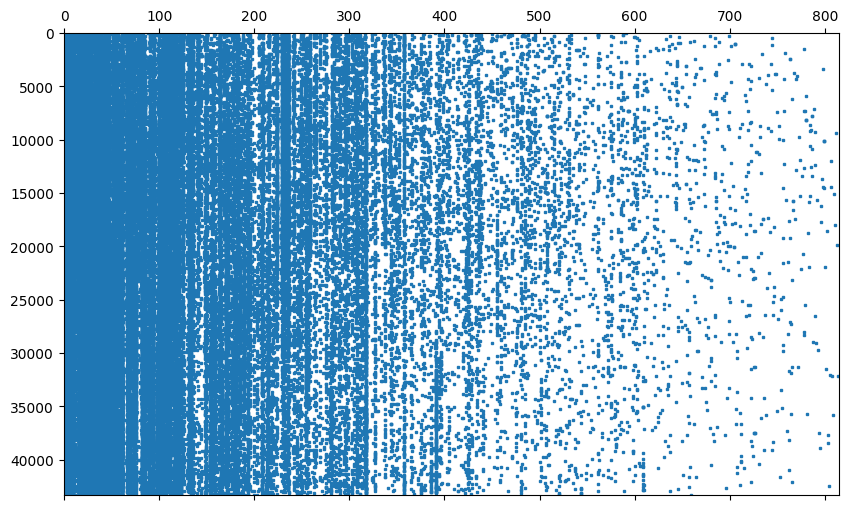

In [10]:
plt.figure(figsize=(10, 6))
plt.spy(all_items_genres_csr, markersize=2)
plt.gca().set_aspect('auto')

### Задание 3/4 - Матрица с весами по жанрам для пользователя

In [59]:
user_id = 1000010

def get_user_items_matrix(user_events):
    user_items = items[items["item_id"].isin(user_events["item_id"])]

    user_items_genres_csr = get_item2genre_matrix(genres, user_items)# ваш код здесь #)
    return user_items_genres_csr

user_events = events_train.query("user_id == @user_id")[["item_id", "rating"]]
user_items_genres_csr = get_user_items_matrix(user_events)

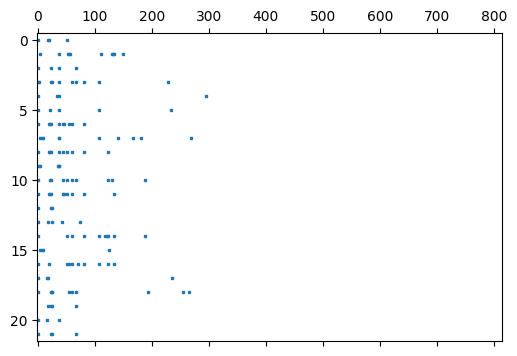

In [50]:
plt.figure(figsize=(6, 4))
plt.spy(user_items_genres_csr, markersize=2)
plt.gca().set_aspect('auto')

### Вычислим предпочтения пользователя по жанрам на основе его истории поведения

In [61]:
# вычислим склонность пользователя к жанрам как среднее взвешенное значение популяции на его оценки книг.

def get_user_genres_scores(user_items_genres_csr, user_events):
    # преобразуем пользовательские оценки из списка в вектор-столбец
    user_ratings = user_events["rating"].to_numpy() / 5
    user_ratings = np.expand_dims(user_ratings, axis=1)

    user_items_genres_weighted = user_items_genres_csr.multiply(user_ratings)
    user_genres_scores = np.asarray(user_items_genres_weighted.mean(axis=0))

    return user_genres_scores

user_events = events_train.query("user_id == @user_id")[["item_id", "rating"]]
user_genres_scores = get_user_genres_scores(user_items_genres_csr, user_events)

# view top 10 
user_genres_scores[0][range(10)]

array([0.        , 0.18524136, 0.00395576, 0.        , 0.        ,
       0.05086544, 0.        , 0.        , 0.00468621, 0.01312976])

### Отобразим, какие жанры больше всего нравятся пользователю

In [52]:
# выведем список жанров, которые предпочитает пользователь

def get_user_genres(user_genres_scores, genres):
    user_genres = genres.copy()
    user_genres["user_score"] = np.ravel(user_genres_scores)
    user_genres = user_genres[user_genres["user_score"] > 0].sort_values(by=["user_score"], ascending=False)
    return user_genres

user_genres = get_user_genres(user_genres_scores, genres)
user_genres.head(10)

,name,votes,score,user_score
genre_id,,,,
1,Fiction,6406698,0.139821,0.185241
38,Classics,3415071,0.074531,0.103879
25,Fantasy,6850115,0.149498,0.072447
5,Nonfiction,1737798,0.037926,0.050865
24,Science Fiction,1218997,0.026604,0.040920
37,Philosophy,379928,0.008292,0.032669
20,Mystery,1371370,0.029929,0.030963
16,Historical-Historical Fiction,1531489,0.033423,0.022008
18,Young Adult,3297027,0.071955,0.021246


### Задание 4/4 - Получите наиболее релевантные рекомендации для пользователя
- Дополните код так, чтобы переменная top_k_indices заполнялась индексами соответствующих книг. 
- Для этого удобно использовать np.argsort от similarity_scores, подсчитанной для всех книг.
- После вычисления top_k_indices по полученным индексам извлеките список объектов, которые могут быть интересны пользователю

In [109]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def get_user_recs_items_indices(user_genres_scores, all_items_genres_csr):

    # вычисляем сходство между вектором пользователя и векторами по книгам
    similarity_scores = cosine_similarity(all_items_genres_csr, user_genres_scores)
    #similarity_scores = euclidean_distances(all_items_genres_csr, user_genres_scores)

    # преобразуем в одномерный массив
    similarity_scores = similarity_scores.flatten()

    # получаем индексы top-k (по убыванию значений), по сути, индексы книг (encoded)
    k = 5
    # cosine similarity is closer at 1 - so take reverse order items
    top_k_indices = np.argsort(similarity_scores)[-(k+1):][::-1] # ваш код здесь #
    
    # euclidean
    #top_k_indices = np.argsort(similarity_scores)[:k]
    return top_k_indices

top_k_indices = get_user_recs_items_indices(user_genres_scores, all_items_genres_csr)

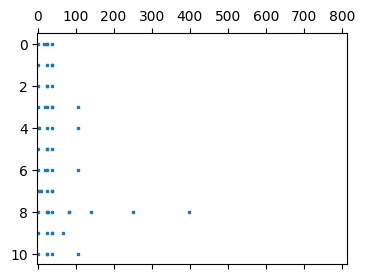

In [57]:
plt.figure(figsize=(4,3))
plt.spy(all_items_genres_csr[top_k_indices], markersize=2)
plt.gca().set_aspect('auto')

In [95]:
def show_user_rec_items(top_k_indices):
    selected_items = items[items["item_id_enc"].isin(top_k_indices)]

    with pd.option_context("max_colwidth", 100):
        display("user recomended items:", selected_items[['item_id', 'author', 'title', 'description', 'genre_and_votes', 'average_rating']])

show_user_rec_items(top_k_indices)

'user recomended items:'

,item_id,author,title,description,genre_and_votes,average_rating
469132,7141417,Meša Selimović,Magla i mjesečina,"""Sve sto je izvan dohvata nase ruke, sve sto nije potpuno nase, s cim nismo srasli tako da posta...",None,4.22
2156619,28688213,Lucian Bane,Desecrating Solomon II,"On the seventh day, of the seventh year... she desecrates\nSolomon and Chaos find themselves in ...",None,4.56
17650,28800321,Dan Carr,New Horizons,17-year-old Val Campbell is a high school drop-out without any prospects before she is taken fro...,None,4.16
1444432,28943950,Alex Letner,FIRST HALF: Super Indy,,None,3.00
615957,29099920,Jason Pere,Calling the Reaper (First Book of Purgatory 1),,None,4.35


Какой жанр преобладает в полученных рекомендациях?

In [69]:
def get_top_rec_genres(top_items_indices, all_items_genres_csr, genres):
    # 1 - взять item_id - для топ-книг - их индексы это top_item_indices
    # 2 - получить по ним матрицу жанров 
    # 3 - вычислить для них среднее значение жанров на выборке из этих книг
    #   - получим среднее значение для жанров этого набор книг
    top_genres = all_items_genres_csr[top_items_indices].mean(axis=0)

    # 4 - объединить полученные оценки с таблице жанров, чтобы потом взять топ из них
    top_rec_genres = genres.copy()
    top_rec_genres["top_items_score"] = np.ravel(top_genres)

    # 5 - отсортировать полученные жанры по величине оценки
    top_rec_genres = top_rec_genres[top_rec_genres["top_items_score"] > 0].sort_values(by=["top_items_score"], ascending=False)
    return top_rec_genres.head(5)

top_rec_genres = get_top_rec_genres(top_k_indices, all_items_genres_csr, genres)
top_rec_genres

,name,votes,score,top_items_score
genre_id,,,,
1,Fiction,6406698,0.139821,0.445889
38,Classics,3415071,0.074531,0.250238
25,Fantasy,6850115,0.149498,0.133989
24,Science Fiction,1218997,0.026604,0.081668
37,Philosophy,379928,0.008292,0.025761


### Факультативное задание - эксперименты с разными пользователями
- Получите по алгоритму выше рекомендации для нескольких пользователей, 
    - просмотрите их на экране. 
    - Подумайте, насколько релевантны и интересны полученные рекомендации пользователям.
- Попробуйте использовать другую меру сходства для получения рекомендаций, 
    - например, евклидово расстояние. 
    - Проанализируйте, отличаются ли рекомендации от предыдущих. Подумайте почему.
- Задайте собственные предпочтения для наиболее популярных жанров. 
    - Посмотрите рекомендации для себя. 
    - Прочитали ли бы вы рекомендованные книги?

In [81]:
user_id = 1035001

user_events = events_train.query("user_id == @user_id")[["item_id", "rating"]]
top_user_books = user_events.merge(items, on='item_id')[['item_id', 'rating', 'author', 'title', 'description', 'genre_and_votes', 'average_rating']].sort_values(by='rating', ascending=False)[:5]

display('top user books', top_user_books)

user_items_genres_csr = get_user_items_matrix(user_events)
user_genres_scores = get_user_genres_scores(user_items_genres_csr, user_events)
user_genres = get_user_genres(user_genres_scores, genres)
display("user prefered genres:", user_genres.head(5))

top_k_indices = get_user_recs_items_indices(user_genres_scores, all_items_genres_csr)
show_user_rec_items(top_k_indices)

top_rec_genres = get_top_rec_genres(top_k_indices, all_items_genres_csr, genres)
display("genres of user recomeneded items", top_rec_genres)

'top user books'

,item_id,rating,author,title,description,genre_and_votes,average_rating
11,23156040,5,"Elena Ferrante, Ann Goldstein",Those Who Leave and Those Who Stay (The Neapol...,"Since the publication of My Brilliant Friend, ...","{'Fiction': 1200, 'Cultural-Italy': 373, 'Hist...",4.29
12,17465515,5,"Elena Ferrante, Ann Goldstein",The Story of a New Name (The Neapolitan Novels...,"The second book, following last year's My Bril...","{'Fiction': 1457, 'Cultural-Italy': 447, 'Hist...",4.36
20,24612118,5,Lauren Groff,Fates and Furies,Every story has two sides. Every relationship ...,"{'Fiction': 2376, 'Contemporary': 436, 'Litera...",3.56
28,18507827,5,Mira Jacob,The Sleepwalker's Guide to Dancing,Spanning India in the 70s to New Mexico in the...,"{'Fiction': 430, 'Historical-Historical Fictio...",3.99
31,2657,5,Harper Lee,To Kill a Mockingbird,The unforgettable novel of a childhood in a sl...,"{'Classics': 41773, 'Fiction': 21733, 'Histori...",4.26


'user prefered genres:'

,name,votes,score,user_score
genre_id,,,,
1,Fiction,6406698,0.139821,0.169550
5,Nonfiction,1737798,0.037926,0.116766
18,Young Adult,3297027,0.071955,0.056796
25,Fantasy,6850115,0.149498,0.029705
16,Historical-Historical Fiction,1531489,0.033423,0.026909


'user recomended items:'

,author,title,genre_and_votes
348684,Sherman Alexie,Flight,"{'Fiction': 490, 'Young Adult': 237, 'Fantasy': 87, 'Historical-Historical Fiction': 80, 'Scienc..."
192801,"Amanda Davis, Michael Chabon",Wonder When You'll Miss Me,"{'Fiction': 72, 'Young Adult': 18}"
1571516,M.J. Hyland,How the Light Gets In,"{'Fiction': 122, 'Young Adult': 32}"
984559,Jenni Fagan,The Panopticon,"{'Fiction': 247, 'Young Adult': 62, 'Mystery': 46, 'Contemporary': 37, 'Cultural-Scotland': 31}"
975965,"Catherine Ryan Hyde, Cristina Panfilio",Walk Me Home,"{'Fiction': 81, 'Young Adult': 20, 'Contemporary': 12}"
1867326,Chris Bohjalian,"Close Your Eyes, Hold Hands","{'Fiction': 333, 'Young Adult': 76, 'Young Adult-Coming Of Age': 45, 'Contemporary': 42}"


'genres of user recomeneded items'

,name,votes,score,top_items_score
genre_id,,,,
1,Fiction,6406698,0.139821,0.678159
18,Young Adult,3297027,0.071955,0.188110
52,Contemporary,709925,0.015493,0.046390
20,Mystery,1371370,0.029929,0.018125
110,Young Adult-Coming Of Age,9840,0.000215,0.015121


#### Проверка на себе

In [110]:
new_user_id = events['user_id'].max() + 1
print(f'new_user_id: {new_user_id}')

# items: 
#   - 78250	Carlos Castañeda	The Teachings of Don Juan: A Yaqui Way of Know...
#   - 5470	George Orwell, Erich Fromm	1984
#   - 22034	Mario Puzo, Robert Thompson, Peter Bart	The Godfather
#   - 11084145	Walter Isaacson	Steve Jobs

new_events = pd.DataFrame([
    {
    'user_id': new_user_id,
    'item_id': 78250,
    'started_at': '2015-04-01',
    'read_at': '2016-04-01',
    'is_read': True,
    'is_reviewed': True,
    'rating': 5
    },
    {
    'user_id': new_user_id,
    'item_id': 5470,
    'started_at': '2016-06-01',
    'read_at': '2016-09-01',
    'is_read': True,
    'is_reviewed': True,
    'rating': 3
    },
    {
    'user_id': new_user_id,
    'item_id': 22034,
    'started_at': '2017-04-01',
    'read_at': '2017-07-01',
    'is_read': True,
    'is_reviewed': True,
    'rating': 4
    },
    {
    'user_id': new_user_id,
    'item_id': 11084145,
    'started_at': '2013-04-01',
    'read_at': '2013-08-01',
    'is_read': True,
    'is_reviewed': True,
    'rating': 4
    }
    ])
user_events = new_events[["item_id", "rating"]]
top_user_books = user_events.merge(items, on='item_id')[['item_id', 'rating', 'author', 'title', 'description', 'genre_and_votes', 'average_rating']].sort_values(by='rating', ascending=False)[:5]

display('top user books', top_user_books)

user_items_genres_csr = get_user_items_matrix(user_events)
user_genres_scores = get_user_genres_scores(user_items_genres_csr, user_events)
user_genres = get_user_genres(user_genres_scores, genres)
display("user prefered genres:", user_genres.head(5))

top_k_indices = get_user_recs_items_indices(user_genres_scores, all_items_genres_csr)
show_user_rec_items(top_k_indices)

top_rec_genres = get_top_rec_genres(top_k_indices, all_items_genres_csr, genres)
display("genres of user recomeneded items", top_rec_genres)

new_user_id: 1430585


'top user books'

,item_id,rating,author,title,description,genre_and_votes,average_rating
0,78250,5,Carlos Castañeda,The Teachings of Don Juan: A Yaqui Way of Know...,Decades ago the University of California Press...,"{'Philosophy': 284, 'Spirituality': 274, 'Nonf...",3.94
2,22034,4,"Mario Puzo, Robert Thompson, Peter Bart",The Godfather,The Godfather--the epic tale of crime and betr...,"{'Fiction': 3705, 'Classics': 1851, 'Mystery-C...",4.36
3,11084145,4,Walter Isaacson,Steve Jobs,From best-selling author Walter Isaacson comes...,"{'Biography': 1696, 'Business': 1625, 'Nonfict...",4.10
1,5470,3,"George Orwell, Erich Fromm",1984,"The year 1984 has come and gone, but George Or...","{'Classics': 33441, 'Fiction': 21086, 'Science...",4.14


'user prefered genres:'

,name,votes,score,user_score
genre_id,,,,
38,Classics,3415071,0.074531,0.137294
1,Fiction,6406698,0.139821,0.128068
5,Nonfiction,1737798,0.037926,0.078857
8,Biography,286843,0.006260,0.070809
53,Business,151053,0.003297,0.061987


'user recomended items:'

,item_id,author,title,description,genre_and_votes,average_rating
1426251,667,Ayn Rand,Anthem,"Anthemhas long been hailed as one of Ayn Rand's classic novels, and a clear predecessor to her l...","{'Fiction': 2380, 'Classics': 2042, 'Philosophy': 873, 'Science Fiction-Dystopia': 837, 'Science...",3.62
1111341,5472,"George Orwell, Christopher Hitchens",Animal Farm / 1984,This edition features George Orwell's best known novels - 1984and Animal Farm- with an introduct...,"{'Classics': 1149, 'Fiction': 828, 'Science Fiction-Dystopia': 166, 'Science Fiction': 144, 'Lit...",4.26
762275,13041,Hermann Hesse,Demian / Siddhartha,,"{'Fiction': 43, 'Classics': 34, 'Philosophy': 13, 'Literature': 8}",4.17
1192014,17690,"Franz Kafka, Max Brod, Willa Muir, Edwin Muir",The Trial,"Written in 1914 but not published until 1925, a year after Kafka's death, The Trial is the terri...","{'Classics': 4607, 'Fiction': 4173, 'Literature': 842, 'Philosophy': 771, 'European Literature-G...",3.98
212202,49552,"Albert Camus, Matthew Ward",The Stranger,This is an alternate cover edition for .\nThrough the story of an ordinary man unwittingly draw...,"{'Classics': 9409, 'Fiction': 8382, 'Philosophy': 4463, 'Cultural-France': 1940, 'Literature': 1...",3.96
1542683,52036,"Hermann Hesse, Hilda Rosner",Siddhartha,Siddhartha\nEste libro electronico tiene una mesa activa de los contenidos\nSiddhartha es una no...,"{'Classics': 6380, 'Fiction': 6326, 'Philosophy': 3332, 'Religion': 1209, 'Spirituality': 1171, ...",3.99


'genres of user recomeneded items'

,name,votes,score,top_items_score
genre_id,,,,
38,Classics,3415071,0.074531,0.371944
1,Fiction,6406698,0.139821,0.359849
37,Philosophy,379928,0.008292,0.112514
107,Literature,191070,0.004170,0.056096
67,Science Fiction-Dystopia,427137,0.009322,0.031911


Проблема в том, что при еквлидовом расстоянии подбираются объекты у которых нет жанров вообще - это не удобно .. - но видимо расстояние они дают минимальное, поэтому используем косинусное

# === Базовые подходы: валидация

## Урок 4/5 - Валидация

### Метрики классификации ("попадания")
#### Посчитаем Recall и Precision для выполненных ранее ALS-рекомендации	

- Посчитаем Recall и Precision для выполненных ранее ALS-рекомендации	
    - используем als_recommendations
    - события в тестовой выборке и рекомендации для одних и тех же пользователей разметим признаками
        - gt (ground truth) - объект есть в тестовой выборке
        - pr (predicted) - объект есть в рекомендациях
    - далее разметим признаки бинарной классификакции
        - TP - истинная рекомендация - объект есть и в тестовой выборке и в рекомендациях
        - FP - ложно-положительная рекомендация - объекта нет в тестовой выборке, но есть в рекомендациях
        - FN - ложно-отрицательный - объекта нет в рекомендациях, но есть в тестовой выборке

In [ ]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):

    """
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    """

    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    print(f"Common users: {len(common_users)}")
    
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    # оставляет только те item_id, которые были в events_train, 
    # т. к. модель не имела никакой возможности давать рекомендации для новых айтемов
    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

Обработаем ALS-рекомендации для подсчёта метрик для 5 лучших рекомендаций:

In [51]:
path = 'data/recomendations-als/'
als_recommendations = pd.read_parquet(path + "als_recommendations.parquet")
als_recommendations

,user_id,item_id,score
0,1000000,3,0.990941
1,1000000,15881,0.896617
2,1000000,5,0.864404
3,1000000,6,0.822254
4,1000000,2,0.774095
...,...,...,...
43058495,1430584,13206900,0.096082
43058496,1430584,5060378,0.096065
43058497,1430584,16071764,0.094949
43058498,1430584,9969571,0.094927


In [54]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
    events_train,
    events_test, 
    als_recommendations, 
    top_k=5)

events_recs_for_binary_metrics

/tmp/ipykernel_3705/3166051426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 123223


,user_id,item_id,gt,score,pr,tp,fp,fn
0,1196635,18467802,True,NaN,False,False,False,True
1,1188739,10799,True,NaN,False,False,False,True
2,1001879,13206828,True,NaN,False,False,False,True
3,1001879,13206900,True,NaN,False,False,False,True
4,1001879,13206760,True,NaN,False,False,False,True
...,...,...,...,...,...,...,...,...
1030163,1430584,29056083,False,0.472945,True,False,True,False
1030164,1430584,17167166,False,0.463936,True,False,True,False
1030165,1430584,17927395,False,0.460429,True,False,True,False
1030166,1430584,16096824,False,0.454709,True,False,True,False


#### Результат подготовки
- мы получили разметку случившихся в будущем событий (events_test) 
- и рекомендаций (als_recommendations: то есть событий, спрогнозированных как случившиеся в будущем). 
- На их основе можно посчитать precision и recall по формулам. 
- Ниже дана заготовка функции, которая считает эти метрики. 
- На вход ей подаётся результат выполнения функции process_events_recs_for_binary_metrics.

### Задание - Метрики precision@5, recall@5
- Дополните код функции compute_cls_metrics для расчёта recall. 
- Получите значения метрик precision@5, recall@5.

In [67]:
def compute_cls_metrics(events_recs_for_binary_metric):
    
    groupper = events_recs_for_binary_metric.groupby("user_id")

    # precision = tp / (tp + fp)
    precision = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fp"].sum())
    precision = precision.fillna(0).mean()
    
    # recall = tp / (tp + fn)
    recall = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fn"].sum()) # ваш код здесь #
    recall = recall.fillna(0).mean()

    return precision, recall

Какое получилось значение для recall@5? Ответ округлите до тысячных.

In [70]:
precision, recall = compute_cls_metrics(events_recs_for_binary_metrics)
('precision', round(precision,3)), ('recall', round(recall,3))


(('precision', 0.008), ('recall', 0.014))

### Факультативное задание - метрики precision@10, recall@10. 
- Сравните их значения со значениями для precision@5, recall@5. Подумайте о причинах таких отличий.

In [73]:
events_recs_for_binary_metrics_10 = process_events_recs_for_binary_metrics(
    events_train,
    events_test, 
    als_recommendations, 
    top_k=10)
precision, recall = compute_cls_metrics(events_recs_for_binary_metrics_10)
('precision', round(precision,3)), ('recall', round(recall,3))

/tmp/ipykernel_3705/3166051426.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 123223


(('precision', 0.009), ('recall', 0.031))

# === Двухстадийный подход: метрики

# === Двухстадийный подход: модель

# === Двухстадийный подход: построение признаков